# Разработка A/B-тестирования и анализ результатов

- Автор: Кривенко Виктория

**Цель проекта** — рассчитать параметры A/B-теста для проверки гипотезы о том, что новый алгоритм рекомендаций повышает вовлечённость пользователей, и проанализировать результаты эксперимента, чтобы дать обоснованную рекомендацию по внедрению нового алгоритма.

**Задачи:**
- изучить исторические данные о сессиях пользователей и определить ключевые продуктовые метрики;
- рассчитать необходимый размер выборки и длительность A/B-теста;
- проверить корректность проведения теста (равномерность распределения пользователей по группам, устройствам и регионам);
- сравнить ключевую метрику между группами и проверить статистическую значимость различий;
- сформулировать вывод и рекомендацию по внедрению нового алгоритма рекомендаций.

## Описание данных


- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработаем с историческими данными приложения:

- Импортируем библиотеки.

- Сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведем на экран первые пять строк полученного датафрейма.

In [1]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# выгружаем данные из датасета sessions_project_history.csv в датафрейм sessions_history
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

# выводим первые строки датафрейма на экран
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [3]:
# для каждого пользователя рассчитываем количество уникальных сессий
session_counts = sessions_history.groupby('user_id')['session_id'].nunique()
session_counts

user_id
00005FB6A13A6FBE    2
0000B15A18D77ED9    3
0000C4E3A4A571A9    2
000293FAF9E67A81    4
00029C5AE889A6C3    2
                   ..
FFFCDE7746148710    4
FFFDD413285E753F    3
FFFECBA0F2578AB0    2
FFFEDB68228B5F21    5
FFFF4228DF580C3B    3
Name: session_id, Length: 134039, dtype: int64

In [4]:
# находим пользователя с наибольшим количеством сессий
max_user = session_counts.idxmax()
# выводим все данные для этого пользователя
sessions_history[sessions_history['user_id'] == max_user]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, нам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. 

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразим их на одном графике.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

In [5]:
# считаем всех уникальных пользователей по дням
daily_users = sessions_history.groupby('session_date')['user_id'].nunique()

# считаем зарегистрированных пользователей
daily_registrations = sessions_history[sessions_history['registration_flag'] == 1].groupby('session_date')['user_id'].nunique()

# объединяем эти показатели в один датафрейм
daily_stats = pd.DataFrame({
    'users': daily_users,
    'registrations': daily_registrations})

# cчитаем долю регистраций в процентах
daily_stats['registration_share'] = round(daily_stats['registrations'] / daily_stats['users'] *100,2)

daily_stats 

,users,registrations,registration_share
session_date,,,
2025-08-11,3919,169,4.31
2025-08-12,6056,336,5.55
2025-08-13,8489,464,5.47
2025-08-14,10321,625,6.06
2025-08-15,14065,840,5.97
2025-08-16,12205,916,7.51
2025-08-17,11200,833,7.44
2025-08-18,10839,860,7.93
2025-08-19,12118,831,6.86


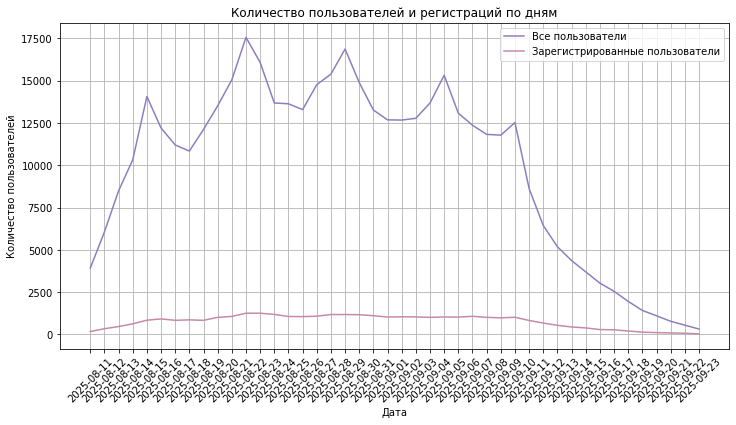

In [6]:
# строим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням
plt.figure(figsize=(12, 6))

plt.plot(
    daily_stats.index,
    daily_stats['users'],
    label='Все пользователи',
    color='#8E7DBE'
)

plt.plot(
    daily_stats.index,
    daily_stats['registrations'],
    label='Зарегистрированные пользователи',
    color='#C48AA8'
)

plt.title('Количество пользователей и регистраций по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid()
plt.legend()

plt.xticks(rotation=45)

plt.show()

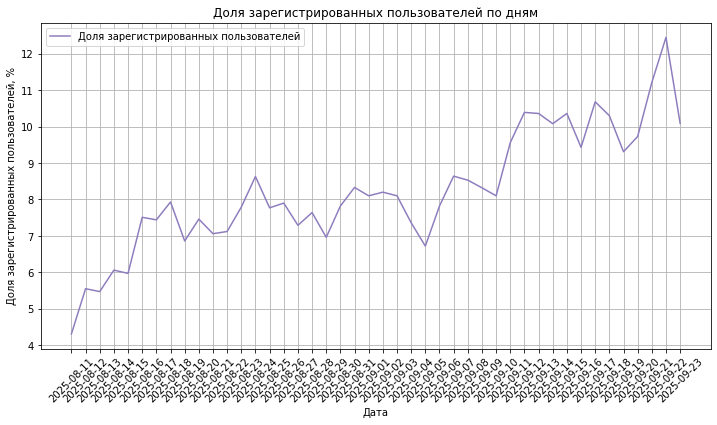

In [7]:
# строим линейный график доли зарегистрированных пользователей от всех пользователей по дням
plt.figure(figsize=(12, 6))

plt.plot(
    daily_stats.index,
    daily_stats['registration_share'],
    label='Доля зарегистрированных пользователей',
    color='#8E7DBE'
    
)

plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователей, %')
plt.grid()
plt.legend()

plt.xticks(rotation=45)

plt.show()

В начале периода **количество пользователей** постепенно увеличивается и достигает максимума 17 563 пользователей 22 августа. После этого наблюдается устойчивое снижение аудитории, к 23 сентября количество пользователей сокращается до 317. 

При этом **количество регистраций** в целом повторяет динамику общего числа пользователей: максимальное значение составляет 1 253 регистрации 23 августа. 

**Доля зарегистрированных пользователей** в начале периода находилась на уровне 4 - 6%, затем постепенно выросла и во второй половине сентября достигла 9 - 12%. Максимальная доля регистраций наблюдается 22 сентября - 12,45%.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц.

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

In [8]:
# оставляем только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# считаем количество первых сессий для каждого количества страниц
page_counts = first_sessions['page_counter'].value_counts().sort_index()

page_counts

1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: page_counter, dtype: int64

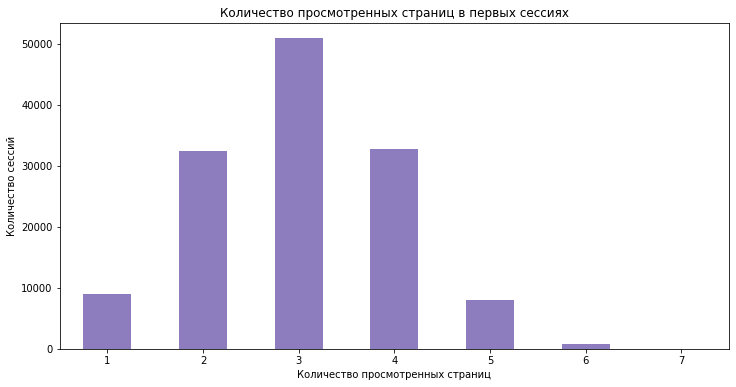

In [9]:
# строим столбчатую диаграмму
plt.figure(figsize=(12, 6))

page_counts.plot(kind='bar', color='#8E7DBE')

plt.title('Количество просмотренных страниц в первых сессиях')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество сессий')

plt.xticks(rotation=0)

plt.show()

В первых сессиях пользователи чаще всего просматривали 3 страницы - 50 939 сессий. На втором месте - 4 страницы (32 739 сессий), на третьем - 2 страницы (32 494 сессии). Значительно реже пользователи просматривали 5 и более страниц: 5 страниц - 8 075 сессий, 6 страниц - 777, 7 страниц - всего 37 сессий.

Таким образом, наиболее типичное количество просмотренных страниц в первой сессии - 3, а большинство первых сессий укладывается в диапазон от 2 до 4 просмотренных страниц.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные визуализируем по дням за весь период наблюдения.

In [10]:
# создаём столбец
sessions_history['good_session'] = 0

# если просмотрено 4 и более страниц - ставим 1
sessions_history.loc[
    sessions_history['page_counter'] >= 4,
    'good_session'
] = 1

# оставляем только первые сессии
first_sessions = sessions_history[
    sessions_history['session_number'] == 1
]

# считаем долю успешных первых сессий по дням
daily_good_sessions = (
    first_sessions.groupby('session_date')['good_session']
    .mean() * 100
)
daily_good_sessions

session_date
2025-08-11    31.283491
2025-08-12    29.834389
2025-08-13    30.686063
2025-08-14    31.909824
2025-08-15    31.111396
2025-08-16    30.842355
2025-08-17    31.934184
2025-08-18    31.308867
2025-08-19    31.436990
2025-08-20    30.910834
2025-08-21    30.900202
2025-08-22    30.950425
2025-08-23    30.213160
2025-08-24    31.641286
2025-08-25    30.665543
2025-08-26    31.816881
2025-08-27    31.470588
2025-08-28    31.428022
2025-08-29    31.366366
2025-08-30    31.067961
2025-08-31    30.592802
2025-09-01    33.178808
2025-09-02    31.512346
2025-09-03    31.018054
2025-09-04    30.996233
2025-09-05    29.961340
2025-09-06    31.561787
2025-09-07    31.079137
2025-09-08    30.174081
2025-09-09    29.738354
2025-09-10    31.004673
Name: good_session, dtype: float64

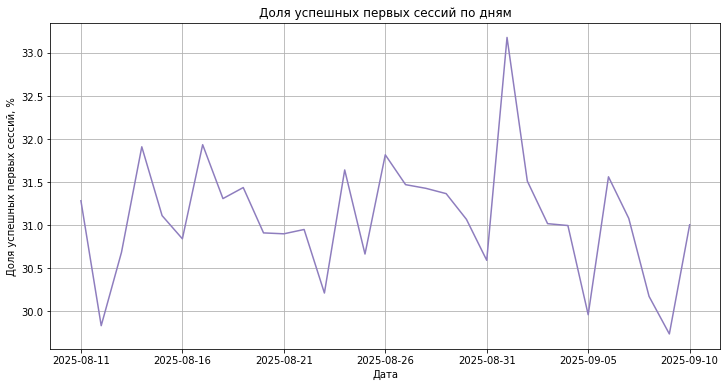

In [11]:
# строим линейный график доли успешных первых сессий по дням
plt.figure(figsize=(12, 6)) 

daily_good_sessions.plot(kind='line', color='#8E7DBE') 

plt.title('Доля успешных первых сессий по дням') 
plt.xlabel('Дата') 
plt.ylabel('Доля успешных первых сессий, %') 
plt.grid()
plt.xticks(rotation=0) 

plt.show()

Доля успешных первых сессий в течение периода наблюдения оставалась относительно стабильной и в основном составляла около 30 - 32%. Минимальное значение - 29,7%, максимальное - 33,2%. 

Выраженной тенденции к росту или снижению показателя не наблюдается.

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
Рассчитаем необходимое для эксперимента количество пользователей.

Для этого установим в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. 

При расчёте размера выборки используем метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

In [12]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задаем параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.3* 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [13]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
daily_users = sessions_history.groupby('session_date')['user_id'].nunique()
avg_daily_users = daily_users.mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((sample_size * 2)/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {avg_daily_users:.0f} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B. Построим визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [14]:
# выгружаем данные из датасета sessions_project_test_part.csv в датафрейм sessions_test_part
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

# количество уникальных пользователей в группе A
sessions_test_part_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()

# количество уникальных пользователей в группе B
sessions_test_part_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

# процентная разница
percentage_diff = (100 * abs(sessions_test_part_A - sessions_test_part_B)/ sessions_test_part_A)

print(f'Группа A: {sessions_test_part_A}')
print(f'Группа B: {sessions_test_part_B}')
print(f'Процентная разница: {percentage_diff:.2f}%')

Группа A: 1477
Группа B: 1466
Процентная разница: 0.74%


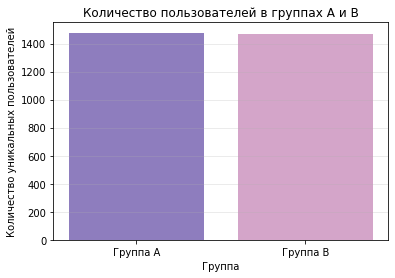

In [15]:
# строим столбчатую диаграмму
plt.bar(
    ['Группа A', 'Группа B'],
    [sessions_test_part_A, sessions_test_part_B],
    color=['#8E7DBE', '#D4A5C9'])

plt.title('Количество пользователей в группах A и B')
plt.xlabel('Группа')
plt.ylabel('Количество уникальных пользователей')

plt.grid(axis='y', alpha=0.3)

plt.show()

В группе **A 1477** уникальных пользователей, в группе **B - 1466**. **Процентная разница составляет 0,74%**, что свидетельствует о равномерном распределении пользователей между экспериментальными группами. 

Существенного дисбаланса между группами не наблюдается.

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [16]:
# пользователи группы A
users_a = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])

# пользователи группы B
users_b = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

# пересечение групп
intersection = users_a & users_b

print(f'Количество пользователей, попавших в обе группы: {len(intersection)}')

Количество пользователей, попавших в обе группы: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.


In [17]:
# оставляем по одному наблюдению для каждого пользователя
users_test_part = sessions_test_part.drop_duplicates('user_id')

# считаем доли устройств в группе A
device_a = round(
    users_test_part[users_test_part['test_group'] == 'A']['device']
    .value_counts(normalize=True) * 100, 2
)

device_a

Android    44.41
PC         24.98
iPhone     20.04
Mac        10.56
Name: device, dtype: float64

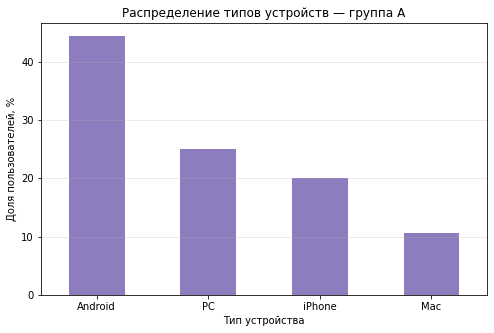

In [18]:
# строим столбчатую диаграмму для группы А
plt.figure(figsize=(8, 5))

device_a.plot(
    kind='bar',
    color='#8E7DBE'
)

plt.title('Распределение типов устройств — группа A')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей, %')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [19]:
# считаем доли устройств в группе B
device_b = round(
    users_test_part[users_test_part['test_group'] == 'B']['device']
    .value_counts(normalize=True) * 100, 2
)

device_b

Android    45.57
PC         25.99
iPhone     18.35
Mac        10.10
Name: device, dtype: float64

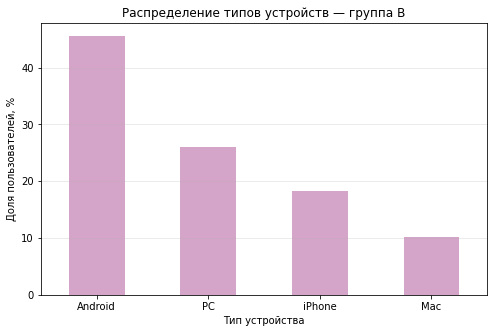

In [20]:
# строим столбчатую диаграмму для группы B
plt.figure(figsize=(8, 5))

device_b.plot(
    kind='bar',
    color='#D4A5C9'
)

plt.title('Распределение типов устройств — группа B')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей, %')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

Распределение пользователей по типам устройств в группах A и B достаточно близкое. Наиболее заметное различие наблюдается для iPhone - 20,04% в группе A против 18,35% в группе B (1,69 п.п). 

В целом существенного перекоса по устройствам между группами не наблюдается, поэтому можно считать, что пользователи распределены по типам устройств достаточно равномерно.

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

In [21]:
# cчитаем доли регионов в группе A
region_a = round(
    users_test_part[users_test_part['test_group'] == 'A']['region']
    .value_counts(normalize=True) * 100, 2
)

region_a

CIS     43.60
MENA    41.23
EU      15.17
Name: region, dtype: float64

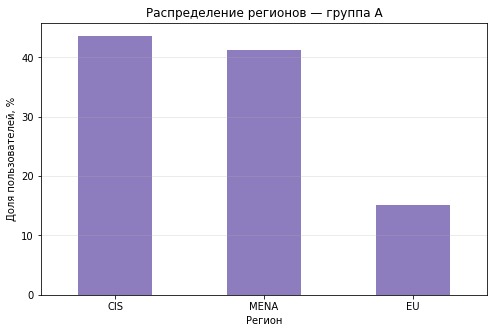

In [22]:
# строим столбчатую диаграмму для группы А
plt.figure(figsize=(8, 5))

region_a.plot(
    kind='bar',
    color='#8E7DBE'
)

plt.title('Распределение регионов — группа A')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей, %')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [23]:
# cчитаем доли регионов в группе B
region_b = round(
    users_test_part[users_test_part['test_group'] == 'B']['region']
    .value_counts(normalize=True) * 100, 2
)

region_b

CIS     44.0
MENA    41.2
EU      14.8
Name: region, dtype: float64

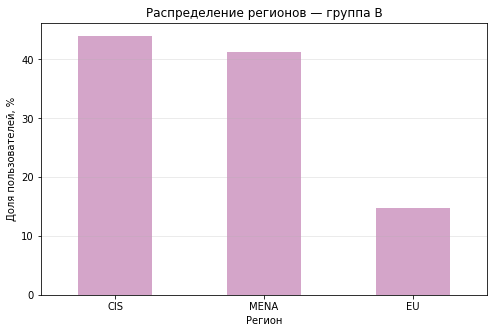

In [24]:
# строим столбчатую диаграмму для группы B
plt.figure(figsize=(8, 5))

region_b.plot(
    kind='bar',
    color='#D4A5C9'
)

plt.title('Распределение регионов — группа B')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей, %')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

**Распределение** пользователей по регионам в группах A и B практически **совпадает**. Максимальная разница наблюдается для CIS и составляет всего 0,40 п.п., для MENA - 0,03 п.п., для EU - 0,37 п.п. 

Существенного дисбаланса между группами не наблюдается, поэтому распределение пользователей по регионам можно считать равномерным.

#### 3.5. Вывод после проверки A/B-теста

В группе A было **1477 пользователей**, в группе B - **1466 пользователей**. Процентная разница между группами составила **0,74%**, поэтому существенного различия в количестве пользователей не обнаружено.

**Пересечений пользователей** между группами A и B **не обнаружено**. Все пользователи относятся только к одной из экспериментальных групп, поэтому выборки являются независимыми.

Распределение пользователей **по типам устройств** в группах A и B в целом совпадает. **Различия** между долями устройств **небольшие**: максимальная разница наблюдается для iPhone и составляет **1,69 п.п**.

**По регионам** распределение пользователей в группах также практически совпадает. Доля пользователей из CIS составляет 43,60% в группе A и 44,00% в группе B, из MENA - 41,23% и 41,20%, из EU - 15,17% и 14,80% соответственно. Максимальная разница составляет всего 0,40 п.п. для CIS, поэтому **существенного дисбаланса** по регионам **не обнаружено.**

**Итог:** A/B-тест проходит корректно: группы имеют практически одинаковый размер, пользователи не пересекаются, а распределение пользователей по устройствам и регионам в группах A и B сопоставимо. Существенных нарушений, которые могли бы повлиять на результаты эксперимента, не обнаружено.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [25]:
# выгружаем данные из датасета sessions_project_test.csv в датафрейм sessions_test
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

# создаем дополнительный столбец 
sessions_test['good_session'] = 0

# если просмотрено 4 и более страниц - ставим 1
sessions_test.loc[
    sessions_test['page_counter'] >= 4,
    'good_session'
] = 1

# выводим результат
sessions_test[['page_counter', 'good_session']].head(20)

,page_counter,good_session
0,3,0
1,2,0
2,2,0
3,1,0
4,2,0
5,2,0
6,4,1
7,3,0
8,3,0
9,3,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


**Целевая метрика** - доля успешных первых сессий.

**H0:** доля успешных первых сессий в группах A и B не различается.

**H1:** доля успешных первых сессий в группе B выше, чем в группе A.

**Прокси-метрики:** количество просмотренных страниц за сессию и количество сессий на пользователя. Они позволяют дополнительно оценить вовлечённость пользователей.

**Барьерная метрика:** доля зарегистрированных пользователей. При внедрении нового алгоритма она не должна снижаться.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразим на экране.

In [26]:
# оставляем только первые сессии
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

# cчитаем долю успешных первых сессий в группе A
share_a = (first_sessions_test[first_sessions_test['test_group']== 'A']['good_session'].mean())
           
# cчитаем долю успешных первых сессий в группе B
share_b = (first_sessions_test[first_sessions_test['test_group']== 'B']['good_session'].mean())

# cчитаем разницу
difference = (share_b - share_a) * 100
           
# выводим результат
print(f'Доля успешных первых сессий в группе А: {share_a:.2%}')
print(f'Доля успешных первых сессий в группе B: {share_b:.2%}')
print(f'Разница: {difference:.2f}п.п')

Доля успешных первых сессий в группе А: 31.57%
Доля успешных первых сессий в группе B: 31.47%
Разница: -0.11п.п


Доля успешных первых сессий в группе B составила 31,47%, что на 0,11 п.п. ниже, чем в группе A (31,57%). 

Таким образом, на уровне описательной статистики после внедрения нового алгоритма наблюдается небольшое снижение ключевой метрики.

#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге мы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведем на экран полученное значение p-value и свои выводы о статистической значимости. 

In [27]:
# количество успешных первых сессий
m_a = first_sessions_test[
    (first_sessions_test['test_group'] == 'A') &
    (first_sessions_test['good_session'] == 1)
].shape[0]
m_b = first_sessions_test[
    (first_sessions_test['test_group'] == 'B') &
    (first_sessions_test['good_session'] == 1)
].shape[0]

# общее количество первых сессий
n_a = first_sessions_test[
    first_sessions_test['test_group'] == 'A'
].shape[0]
n_b = first_sessions_test[
    first_sessions_test['test_group'] == 'B'
].shape[0]

# проводим Z- тест пропорций
from statsmodels.stats.proportion import proportions_ztest
alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a,m_b],
    [n_a,n_b],
    alternative = 'smaller')

print(f'p_value = {p_value_ztest}')
if p_value_ztest < alpha:
    print('Изменение статистически значимо')
else:
    print('Изменение статистически незначимо')

p_value = 0.5783523649187868
Изменение статистически незначимо


По результатам Z-теста пропорций получено p-value = 0,5784. Поскольку p-value > 0,05, статистически значимых различий между долями успешных первых сессий в группах A и B не обнаружено. 

Следовательно, наблюдаемое снижение ключевой метрики на 0,11 п.п. может быть связано со случайными колебаниями, и оснований считать, что новый алгоритм изменил долю успешных первых сессий, нет.

In [28]:
sessions_test.groupby('test_group')['user_id'].nunique()

test_group
A    15163
B    15416
Name: user_id, dtype: int64

#### 4.5. Вывод по результатам A/B-эксперимента


В рамках A/B-теста сравнивались контрольная группа A и тестовая группа B, в которой использовался новый алгоритм рекомендаций. В эксперименте приняли участие **30 579 пользователей**: 15 163 пользователя в группе A и 15 416 пользователей в группе B. Фактическая длительность эксперимента составила **20 дней** - с 14 октября по 2 ноября 2025 года. При этом расчётный необходимый размер выборки составлял 41 040 пользователей на каждую группу.

**Ключевой метрикой** была выбрана доля успешных первых сессий, в которых пользователь просмотрел 4 и более страниц. В группе **A** она составила **31,57%**, а в группе **B - 31,47%**. Таким образом, после внедрения нового алгоритма ключевая метрика **снизилась на 0,11 п.п.**, хотя ожидалось её увеличение.

Для проверки статистической значимости был проведён односторонний Z-тест пропорций. Полученное значение p-value = 0,5783, что больше уровня значимости α = 0,05. Следовательно, **оснований отвергнуть нулевую гипотезу нет**: статистически значимого увеличения доли успешных первых сессий в группе B не обнаружено.

На основании результатов A/B-теста внедрять новый алгоритм рекомендаций **не рекомендуется**. Новый алгоритм не подтвердил ожидаемого роста ключевой метрики, а наблюдаемое снижение на 0,11 п.п. не является статистически значимым.